# Célula 1 — Imports

In [104]:
from pathlib import Path
import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

import yfinance as yf
import requests

# Célula 2 — Constantes 

In [105]:
START          = "2003-01-02"
END            = "2025-04-14"
TEST_RATIO     = 0.1
SEED           = 42
WINDOW_SIZE    = 20       
TOMORROW_SHIFT = -1
FRED_API_KEY   = "a75bdc9f7da239a5e3d6c8e389345bfb"

DATA_BASE_PATH = Path("./data")

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()

# Célula 3 - Requição para API do FRED

In [106]:
FRED_API_KEY = "a75bdc9f7da239a5e3d6c8e389345bfb"

def get_fred_series(series_id: str, start: str, end: str, api_key: str) -> pd.DataFrame:
    url = "https://api.stlouisfed.org/fred/series/observations"
    params = {
        "series_id": series_id,
        "api_key": api_key,
        "file_type": "json",
        "observation_start": start,
        "observation_end": end,
    }
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()["observations"]
    df = pd.DataFrame(data)[["date", "value"]]
    df.columns = ["timestamp", series_id.lower()]
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df[series_id.lower()] = pd.to_numeric(df[series_id.lower()], errors="coerce")
    return df.reset_index(drop=True)

dfii10 = get_fred_series("DFII10", START, END, FRED_API_KEY)
dfii10 = dfii10.rename(columns={"dfii10": "inflation"})
print(dfii10.shape)
print(dfii10.head())

(5813, 2)
   timestamp  inflation
0 2003-01-02       2.43
1 2003-01-03       2.43
2 2003-01-06       2.46
3 2003-01-07       2.42
4 2003-01-08       2.29


# Células 4, 5, 6 e 7 - Carrega dataframes

In [107]:
petrodolar = pd.read_csv(
    DATA_BASE_PATH / "petrodollar_5_daily_prices_fx.csv",
    parse_dates=["date"]
)
petrodolar = petrodolar.rename(columns={"date": "timestamp"})
petrodolar = petrodolar[[
    "timestamp",
    "brent_crude_usd",
    "wti_crude_usd",
    "brent_wti_spread",
    "usd_dxy_index",
    "eur_usd",
    "usd_rub",
]]
petrodolar = petrodolar[
    (petrodolar["timestamp"] >= START) &
    (petrodolar["timestamp"] <= END)
].reset_index(drop=True)

print(petrodolar.shape)
print(petrodolar.head())

(5813, 7)
   timestamp  brent_crude_usd  wti_crude_usd  brent_wti_spread  usd_dxy_index  \
0 2003-01-02            26.19          21.97              4.22          88.12   
1 2003-01-03            26.42          23.12              3.30          91.02   
2 2003-01-06            26.41          20.85              5.56          90.50   
3 2003-01-07            26.55          23.85              2.70          91.27   
4 2003-01-08            26.25          25.34              0.91          88.42   

   eur_usd  usd_rub  
0   1.1774    29.36  
1   1.1339    28.74  
2   1.1454    28.83  
3   1.1356    29.47  
4   1.1658    28.74  


In [108]:
opec = pd.read_csv(
    DATA_BASE_PATH / "petrodollar_2_opec_quotas_events.csv",
    parse_dates=["date"]
)
opec = opec.rename(columns={"date": "timestamp"})
opec["timestamp"] = pd.to_datetime(opec["timestamp"])
opec = opec[[
    "timestamp",
    "opec_compliance_pct",
    "oil_market_balance_mbd",
    "us_shale_production_mbd",
]].copy()

# Dataset 4 — Dedolarização
dedolar = pd.read_csv(
    DATA_BASE_PATH / "petrodollar_4_dedollarization.csv",
    parse_dates=["date"]
)
dedolar = dedolar.rename(columns={"date": "timestamp"})
dedolar["timestamp"] = pd.to_datetime(dedolar["timestamp"])
dedolar = dedolar[[
    "timestamp",
    "de_dollarization_pressure_index",
    "brics_gold_reserves_tonnes",
    "usd_global_fx_reserves_pct",
]].copy()

# Dataset 3 — SWF (anual)
swf = pd.read_csv(DATA_BASE_PATH / "petrodollar_3_recycling_swf.csv")
swf = swf[["year", "global_fx_reserves_gold_share_pct"]].copy()

print("OPEC:", opec.shape)
print("Dedolar:", dedolar.shape)
print("SWF:", swf.shape)

OPEC: (312, 4)
Dedolar: (252, 4)
SWF: (26, 2)


In [109]:
tickers = {
    "dxy":   "DX-Y.NYB",
    "vix":   "^VIX",
    "oil":   "CL=F",
    "tips":  "TIP",
    "sp500": "^GSPC",
    "tnx": "^TNX",
}

dfs = {}
for name, ticker in tickers.items():
    df = yf.download(ticker, start=START, end=END, auto_adjust=True, progress=False)
    close = df["Close"]
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    close.name = name
    dfs[name] = close

externos = pd.concat(dfs.values(), axis=1)
externos.index.name = "timestamp"
externos = externos.reset_index()

print(externos.shape)
print(externos.head())

(5623, 7)
   timestamp         dxy        vix        oil  tips       sp500    tnx
0 2003-01-02  102.980003  25.389999  31.850000   NaN  909.030029  4.032
1 2003-01-03  102.470001  24.680000  33.080002   NaN  908.590027  4.038
2 2003-01-06  101.970001  24.910000  32.099998   NaN  929.010010  4.066
3 2003-01-07  102.570000  25.129999  31.080000   NaN  922.929993  4.025
4 2003-01-08  101.870003  25.530001  30.559999   NaN  909.929993  3.981


C:\Users\fpaul\AppData\Local\Temp\ipykernel_3032\1791968288.py:19: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  externos = pd.concat(dfs.values(), axis=1)


In [110]:
gold      = pd.read_csv(DATA_BASE_PATH / "final_gold_data.csv",      sep=";", encoding="utf-8", parse_dates=["timestamp"])
palladium = pd.read_csv(DATA_BASE_PATH / "final_palladium_data.csv", sep=";", encoding="utf-8", parse_dates=["timestamp"])
platinum  = pd.read_csv(DATA_BASE_PATH / "final_platinum_data.csv",  sep=";", encoding="utf-8", parse_dates=["timestamp"])
silver    = pd.read_csv(DATA_BASE_PATH / "final_silver_data.csv",    sep=";", encoding="utf-8", parse_dates=["timestamp"])

cols_to_drop = ["currency", "unit", "headlines"]
for name, df in [("palladium", palladium), ("platinum", platinum), ("silver", silver)]:
    df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)
    df.rename(columns={
        "open":   f"{name}_open",
        "high":   f"{name}_high",
        "low":    f"{name}_low",
        "close":  f"{name}_close",
        "volume": f"{name}_volume",
    }, inplace=True)

print("Gold:", gold.shape)

Gold: (6177, 9)


# Célula 8 - Merges

In [111]:
for df in [gold, palladium, platinum, silver, externos]:
    df["timestamp"] = pd.to_datetime(df["timestamp"])

gold = gold.merge(palladium,  on="timestamp", how="left")
gold = gold.merge(platinum,   on="timestamp", how="left")
gold = gold.merge(silver,     on="timestamp", how="left")
gold = gold.merge(externos,   on="timestamp", how="left")
gold = gold.merge(dfii10,     on="timestamp", how="left")
gold = gold.merge(petrodolar, on="timestamp", how="left")

# Merge mensal: OPEC e dedolarização (merge por ano+mês)
gold["year"]  = gold["timestamp"].dt.year
gold["month_"] = gold["timestamp"].dt.month

opec["year"]   = opec["timestamp"].dt.year
opec["month_"] = opec["timestamp"].dt.month
opec = opec.drop(columns=["timestamp"])

dedolar["year"]   = dedolar["timestamp"].dt.year
dedolar["month_"] = dedolar["timestamp"].dt.month
dedolar = dedolar.drop(columns=["timestamp"])

gold = gold.merge(opec,    on=["year", "month_"], how="left")
gold = gold.merge(dedolar, on=["year", "month_"], how="left")
gold = gold.merge(swf,     on="year",             how="left")
gold = gold.drop(columns=["year", "month_"])

fill_cols = [
    "dxy", "vix", "oil", "tips", "sp500", "tnx",
    "palladium_close", "palladium_open", "palladium_high", "palladium_low",
    "platinum_close",  "platinum_open",  "platinum_high",  "platinum_low",
    "silver_close",    "silver_open",    "silver_high",    "silver_low",
    "inflation",
    "brent_crude_usd", "wti_crude_usd", "brent_wti_spread", "usd_dxy_index", "eur_usd", "usd_rub",
    "opec_compliance_pct", "oil_market_balance_mbd", "us_shale_production_mbd",
    "de_dollarization_pressure_index", "brics_gold_reserves_tonnes", "usd_global_fx_reserves_pct",
    "global_fx_reserves_gold_share_pct",
]

gold[fill_cols] = gold[fill_cols].ffill().bfill()
gold = gold.dropna()

print("Shape após merge:", gold.shape)
print(gold.isna().sum()[gold.isna().sum() > 0])

Shape após merge: (5229, 44)
Series([], dtype: int64)


# Célula 9 - Feature Engineering

In [112]:
gold["day_variation"]  = gold["open"] - gold["close"]
gold["max_diff"]       = gold["high"] - gold["low"]
gold["tomorrow_close"] = gold["close"].shift(TOMORROW_SHIFT)
gold = gold.dropna(subset=["tomorrow_close"])

gold["target_return"] = (gold["tomorrow_close"] - gold["close"]) / gold["close"]
gold["month"]         = gold["timestamp"].dt.month

# Médias móveis
gold["sma_5"]     = gold["close"].rolling(5).mean()
gold["sma_20"]    = gold["close"].rolling(20).mean()
gold["sma_ratio"] = gold["sma_5"] / gold["sma_20"]

# MACD
ema_12 = gold["close"].ewm(span=12).mean()
ema_26 = gold["close"].ewm(span=26).mean()
gold["macd"]        = ema_12 - ema_26
gold["macd_signal"] = gold["macd"].ewm(span=9).mean()

# Bollinger Bands
rolling_std         = gold["close"].rolling(20).std()
gold["bb_upper"]    = gold["sma_20"] + 2 * rolling_std
gold["bb_lower"]    = gold["sma_20"] - 2 * rolling_std
gold["bb_position"] = (gold["close"] - gold["bb_lower"]) / (gold["bb_upper"] - gold["bb_lower"])

# ROC
gold["roc_10"] = gold["close"].pct_change(10)

# Taxa real
gold["real_rate_proxy"] = gold["tnx"] - gold["inflation"]

# Petrodólar
gold["petrodolar_brent"] = gold["brent_crude_usd"] / gold["usd_dxy_index"]
gold["petrodolar_wti"]   = gold["wti_crude_usd"]   / gold["usd_dxy_index"]
gold["brent_roc_20"]     = gold["brent_crude_usd"].pct_change(20)
gold["brent_vol_20"]     = gold["brent_crude_usd"].pct_change().rolling(20).std()

# RSI
delta    = gold["close"].diff()
gain     = delta.clip(lower=0)
loss     = -delta.clip(upper=0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs       = avg_gain / avg_loss
gold["rsi_14"] = 100 - (100 / (1 + rs))

# TARGET: volatilidade realizada via log-retornos
gold["log_return"]    = np.log(gold["close"] / gold["close"].shift(1))
gold["target_vol_5d"] = gold["log_return"].rolling(21).std().shift(-21)

gold = gold.dropna()

print("Shape após dropna:", gold.shape)
print("NaN restantes:", gold.isna().sum().sum())

Shape após dropna: (5187, 66)
NaN restantes: 0


# Célula 10 - Target

In [113]:
TARGET = "target_vol_5d"

to_drop = [
    "currency", "unit", "timestamp", "headlines",
    "tomorrow_close", "target_return", "log_return",
]

X = gold.drop(columns=[c for c in to_drop + [TARGET] if c in gold.columns])
y = gold[TARGET]

# Remove features com baixa correlação (apenas as realmente inúteis)
cols_low_corr = [
    "brent_wti_roc_5",
    "day_of_week",
    "day_variation",
    "bb_position",
    "return_lag_1",
    "volume",
    "brent_roc_5",
    "brent_wti_spread",
    "silver_volume",
    "return_lag_5",
    "return_lag_2",
    "return_lag_3",
    "roc_5",
]

#  Remove features redundantes (corr > 0.95)
cols_redundant = [
    "bb_lower", "bb_upper",
    "high", "low", "open",
    "palladium_close", "palladium_low", "palladium_open",
    "platinum_high",   "platinum_low",  "platinum_open",
    "silver_close",    "silver_high",   "silver_open",
]

all_to_drop = list(set(cols_low_corr + cols_redundant))
X = X.drop(columns=[c for c in all_to_drop if c in X.columns])

#  Verificar se 'index' é leakage
if "index" in X.columns:
    print("ATENÇÃO: coluna 'index' encontrada — verificar se é data leakage")
    print(gold[["timestamp", "index"]].head(10))

n_features = X.shape[1]
print("Features restantes:", list(X.columns))
print("n_features:", n_features)

Features restantes: ['close', 'palladium_high', 'palladium_volume', 'platinum_close', 'platinum_volume', 'silver_low', 'dxy', 'vix', 'oil', 'tips', 'sp500', 'tnx', 'inflation', 'brent_crude_usd', 'wti_crude_usd', 'usd_dxy_index', 'eur_usd', 'usd_rub', 'opec_compliance_pct', 'oil_market_balance_mbd', 'us_shale_production_mbd', 'de_dollarization_pressure_index', 'brics_gold_reserves_tonnes', 'usd_global_fx_reserves_pct', 'global_fx_reserves_gold_share_pct', 'max_diff', 'month', 'sma_5', 'sma_20', 'sma_ratio', 'macd', 'macd_signal', 'roc_10', 'real_rate_proxy', 'petrodolar_brent', 'petrodolar_wti', 'brent_roc_20', 'brent_vol_20', 'rsi_14']
n_features: 39


# Célula 11 - Create sequences

In [114]:
# Célula 7 — Sequences + split
def create_sequences(X, y, window_size):
    Xs, ys = [], []
    for i in range(len(X) - window_size):
        Xs.append(X[i:i + window_size])
        ys.append(y.iloc[i + window_size])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X.to_numpy(), y, WINDOW_SIZE)

mask  = ~np.isnan(y_seq)
X_seq = X_seq[mask]
y_seq = y_seq[mask]

print("NaN em y_seq após mask:", np.isnan(y_seq).sum())

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_seq, y_seq, test_size=TEST_RATIO, shuffle=False
)

print("Train:", X_train_full.shape, "Test:", X_test.shape)

NaN em y_seq após mask: 0
Train: (4650, 20, 39) Test: (517, 20, 39)


# Célula 12 - Criação do modelo

In [115]:
def build_model(learning_rate=0.0001):
    model = Sequential([
        Input(shape=(WINDOW_SIZE, n_features)),
        LSTM(32, return_sequences=False),
        Dropout(0.3),
        Dense(16, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate), loss="huber")
    return model

# Célula 13 - Normalização

In [116]:
x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(
    X_train_full.reshape(-1, n_features)
).reshape(X_train_full.shape)
X_test_scaled = x_scaler.transform(
    X_test.reshape(-1, n_features)
).reshape(X_test.shape)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train_full.reshape(-1, 1)).ravel()

print("X_train_scaled:", X_train_scaled.shape)
print("y_train_scaled mean:", y_train_scaled.mean(), "std:", y_train_scaled.std())

X_train_scaled: (4650, 20, 39)
y_train_scaled mean: -3.6673173458585816e-16 std: 0.9999999999999999


# Célula 14 - Separação em treino e teste

In [117]:
tscv = TimeSeriesSplit(n_splits=5)

walk_r2s = []
for fold, (train_idx, test_idx) in enumerate(tscv.split(X_seq)):
    X_tr = X_seq[train_idx]
    X_te = X_seq[test_idx]
    y_tr = y_seq[train_idx]
    y_te = y_seq[test_idx]

    # Escala X
    sc_x = StandardScaler()
    X_tr_s = sc_x.fit_transform(X_tr.reshape(-1, n_features)).reshape(X_tr.shape)
    X_te_s = sc_x.transform(X_te.reshape(-1, n_features)).reshape(X_te.shape)

    # Escala y
    sc_y = StandardScaler()
    y_tr_s = sc_y.fit_transform(y_tr.reshape(-1, 1)).ravel()

    tf.keras.backend.clear_session()
    m = build_model()
    m.fit(
        X_tr_s, y_tr_s,
        epochs=100, batch_size=32,
        validation_split=0.1, shuffle=False, verbose=0,
        callbacks=[EarlyStopping(patience=8, restore_best_weights=True, min_delta=1e-5)]
    )

    pred_s = m.predict(X_te_s, verbose=0)
    pred   = sc_y.inverse_transform(pred_s.reshape(-1, 1)).ravel()

    r2 = r2_score(y_te, pred)
    walk_r2s.append(r2)
    print(f"Fold {fold+1} R²: {r2:.4f}  |  pred_std: {pred.std():.6f}  |  real_std: {y_te.std():.6f}")

print(f"\nR² médio walk-forward: {np.mean(walk_r2s):.4f}")

Fold 1 R²: -0.1683  |  pred_std: 0.000428  |  real_std: 0.010954
Fold 2 R²: -0.4658  |  pred_std: 0.002176  |  real_std: 0.004667
Fold 3 R²: -3.8860  |  pred_std: 0.001389  |  real_std: 0.002183
Fold 4 R²: 0.1368  |  pred_std: 0.001077  |  real_std: 0.004175
Fold 5 R²: -1.4228  |  pred_std: 0.000938  |  real_std: 0.002047

R² médio walk-forward: -1.1612


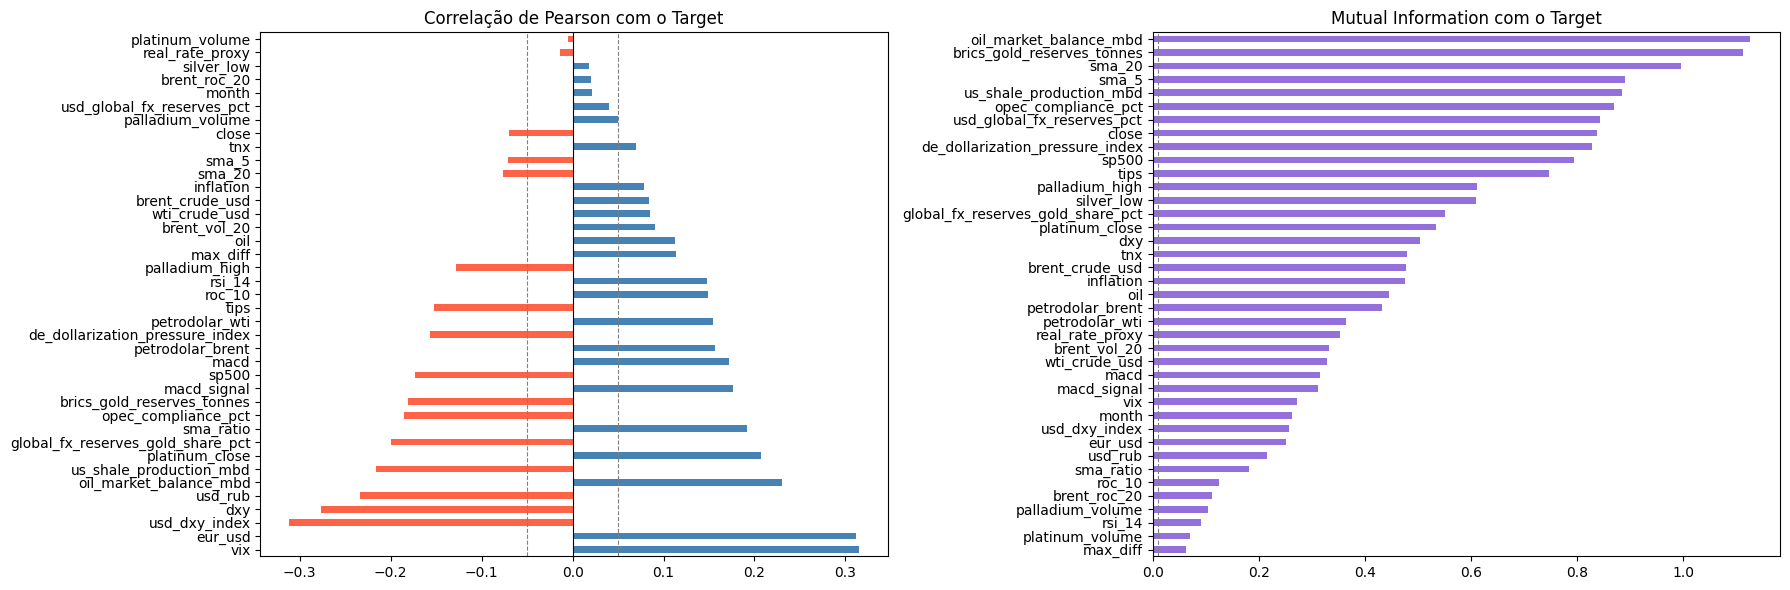

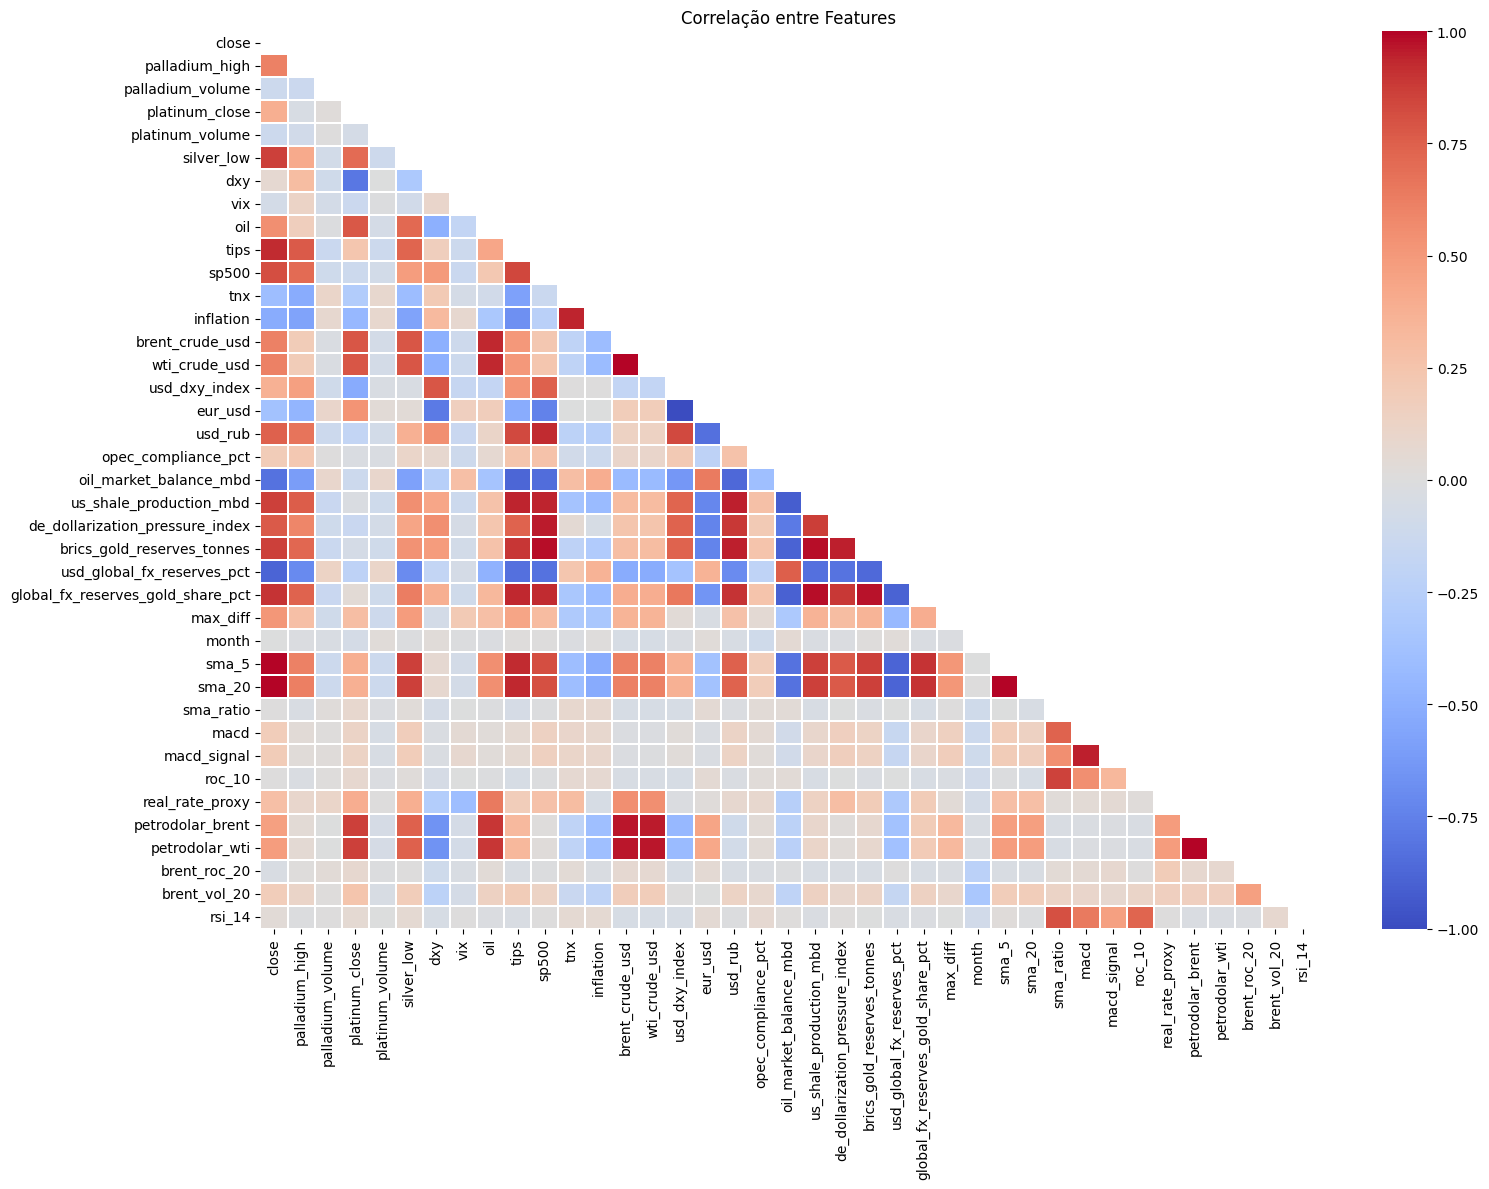

RANKING COMPLETO


,pearson,abs_pearson,mutual_info
oil_market_balance_mbd,0.230730,0.230730,1.125931
brics_gold_reserves_tonnes,-0.180436,0.180436,1.111837
sma_20,-0.076410,0.076410,0.995164
sma_5,-0.070589,0.070589,0.890642
us_shale_production_mbd,-0.216290,0.216290,0.884368
opec_compliance_pct,-0.184973,0.184973,0.868549
usd_global_fx_reserves_pct,0.040385,0.040385,0.842346
close,-0.069838,0.069838,0.836733
de_dollarization_pressure_index,-0.156263,0.156263,0.828072
sp500,-0.173248,0.173248,0.794129



  Features com pearson < 0.05 E mutual_info < 0.01:


,pearson,abs_pearson,mutual_info


In [139]:
from sklearn.feature_selection import mutual_info_regression
import seaborn as sns

# ── 1. Correlação de Pearson com o target ────────────────────────────────────
corr_target = X.corrwith(y).sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

corr_target.plot(kind="barh", ax=axes[0], color=[
    "steelblue" if v > 0 else "tomato" for v in corr_target
])
axes[0].set_title("Correlação de Pearson com o Target")
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].axvline( 0.05, color="gray", linewidth=0.8, linestyle="--")
axes[0].axvline(-0.05, color="gray", linewidth=0.8, linestyle="--")

# ── 2. Mutual Information ────────────────────────────────────────────────────
mi = mutual_info_regression(X, y, random_state=42)
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=True)

mi_series.plot(kind="barh", ax=axes[1], color="mediumpurple")
axes[1].set_title("Mutual Information com o Target")
axes[1].axvline(0.01, color="gray", linewidth=0.8, linestyle="--")

plt.tight_layout()
plt.show()

# ── 3. Heatmap de correlação entre features ──────────────────────────────────
plt.figure(figsize=(16, 12))
corr_matrix = X.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # só triângulo inferior

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    annot=False,
    linewidths=0.3,
)
plt.title("Correlação entre Features")
plt.tight_layout()
plt.show()

# ── 4. Tabela resumo ─────────────────────────────────────────────────────────
summary = pd.DataFrame({
    "pearson":     corr_target,
    "abs_pearson": corr_target.abs(),
    "mutual_info": pd.Series(mi, index=X.columns),
}).sort_values("mutual_info", ascending=False)

print("="*60)
print("RANKING COMPLETO")
print("="*60)
display(summary)

print("\n  Features com pearson < 0.05 E mutual_info < 0.01:")
weak = summary[(summary["abs_pearson"] < 0.05) & (summary["mutual_info"] < 0.01)]
display(weak)

# Célula 15 - Treino

In [118]:
# Célula 10 — Treino
tf.keras.backend.clear_session()
final_model = build_model()

early_stop = EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True, min_delta=1e-5
)

history = final_model.fit(
    X_train_scaled, y_train_scaled,
    validation_split=0.2,   # era 0.1
    epochs=300,
    batch_size=64,           # era 32 — batch maior = menos overfitting
    callbacks=[early_stop],
    shuffle=False,
    verbose=1
)

Epoch 1/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.3629 - val_loss: 0.2464
Epoch 2/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.3365 - val_loss: 0.2509
Epoch 3/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.3200 - val_loss: 0.2522
Epoch 4/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.3108 - val_loss: 0.2520
Epoch 5/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.3007 - val_loss: 0.2535
Epoch 6/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.2945 - val_loss: 0.2541
Epoch 7/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.2911 - val_loss: 0.2511
Epoch 8/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.2861 - val_loss: 0.2482
Epoch 9/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.2818 - val_loss: 0.2398
Epoch 10/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.2757 - val_loss: 0.2346
Epoch 11/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.2745 - val_loss: 0.2316
Epoch 12/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

# Célula 16 - Métricas

In [119]:
y_pred_train = y_scaler.inverse_transform(
    final_model.predict(X_train_scaled)
).flatten()

y_pred_test = y_scaler.inverse_transform(
    final_model.predict(X_test_scaled)
).flatten()

print("Pred treino std:", y_pred_train.std())
print("Real treino std:", y_train_full.std())
print("Pred teste  std:", y_pred_test.std())
print("Real teste  std:", y_test.std())

for name, y_true, y_pred in [
    ("TRAIN", y_train_full, y_pred_train),
    ("TEST",  y_test,       y_pred_test)
]:
    print(f"\n{'='*60}\n{name} METRICS\n{'='*60}")
    print("MAE:  ", mean_absolute_error(y_true, y_pred))
    print("RMSE: ", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2:   ", r2_score(y_true, y_pred))
    baseline = np.full_like(y_true, fill_value=y_train_full.mean())
    print("R2 baseline:", r2_score(y_true, baseline))
    corr = np.corrcoef(y_true, y_pred)[0, 1]
    print("Correlação pred vs real:", corr)

146/146 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Pred treino std: 0.0025894488
Real treino std: 0.0059949753901572455
Pred teste  std: 0.00054952153
Real teste  std: 0.0022216339480142506

TRAIN METRICS
MAE:   0.002375649094225045
RMSE:  0.004751183567724221
R2:    0.3718999742328437
R2 baseline: 0.0
Correlação pred vs real: 0.6656298147066925

TEST METRICS
MAE:   0.0018791960384300138
RMSE:  0.0024270561416500002
R2:    -0.19347860650761572
R2 baseline: -0.5445500645715247
Correlação pred vs real: 0.13496050601800122


In [120]:
print("mean pred:", pred.mean())
print("std pred :", pred.std())
print("mean real:", y_te.mean())
print("std real :", y_te.std())

mean pred: 0.0110334335
std pred : 0.0009375201
mean real: 0.00893555185834059
std real : 0.0020467532940193


In [121]:
print(pred[:20].flatten())

[0.00962748 0.00966273 0.00962001 0.00963096 0.00963627 0.00968575
 0.00964544 0.00973546 0.00989313 0.00985891 0.00983399 0.00983807
 0.00987353 0.00991833 0.00995283 0.01001567 0.01016957 0.01022263
 0.01031777 0.01042458]


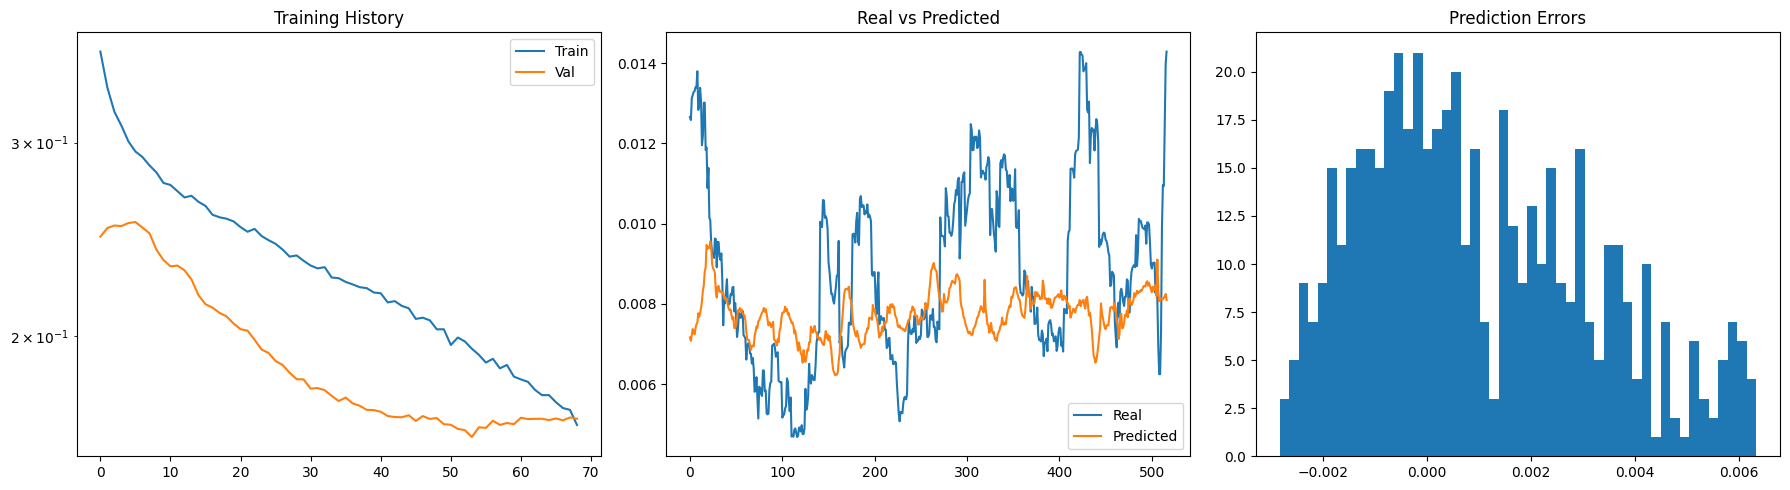

In [122]:
# Célula 12 — Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_yscale('log')
axes[0].set_title("Training History")
axes[0].legend()

axes[1].plot(y_test,                label="Real")
axes[1].plot(y_pred_test.flatten(), label="Predicted")
axes[1].set_title("Real vs Predicted")
axes[1].legend()

errors = y_test - y_pred_test.flatten()
axes[2].hist(errors, bins=50)
axes[2].set_title("Prediction Errors")

plt.tight_layout()
plt.show()

In [123]:
print("TARGET")
print("mean:", y_te.mean())
print("std :", y_te.std())

print()

print("PRED")
print("mean:", pred.mean())
print("std :", pred.std())

print()
print("R2:", r2_score(y_te, pred))

TARGET
mean: 0.00893555185834059
std : 0.0020467532940193

PRED
mean: 0.0110334335
std : 0.0009375201

R2: -1.422770130607255


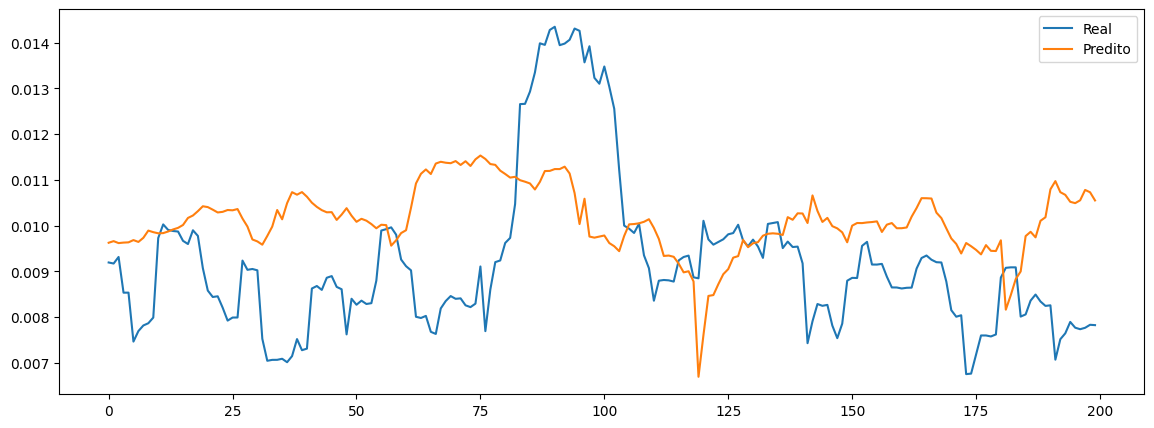

In [124]:
plt.figure(figsize=(14,5))

plt.plot(y_te[:200], label="Real")
plt.plot(pred[:200], label="Predito")

plt.legend()
plt.show()

In [125]:
# Célula 13 — Diagnóstico de correlações
corr = pd.DataFrame(X.values, columns=X.columns)
corr["target"] = y.values[:len(corr)]
correlations = corr.corr()["target"].drop("target").sort_values(key=abs, ascending=False)
correlations

vix                                  0.314904
eur_usd                              0.312043
usd_dxy_index                       -0.311860
dxy                                 -0.276924
usd_rub                             -0.233919
oil_market_balance_mbd               0.230730
us_shale_production_mbd             -0.216290
platinum_close                       0.207287
global_fx_reserves_gold_share_pct   -0.199277
sma_ratio                            0.191878
opec_compliance_pct                 -0.184973
brics_gold_reserves_tonnes          -0.180436
macd_signal                          0.175990
sp500                               -0.173248
macd                                 0.171470
petrodolar_brent                     0.156390
de_dollarization_pressure_index     -0.156263
petrodolar_wti                       0.154306
tips                                -0.152108
roc_10                               0.149139
rsi_14                               0.147357
palladium_high                    

In [126]:
print("Período completo:", gold["timestamp"].min(), "→", gold["timestamp"].max())
print("Linhas total:", len(gold))
print("\nÚltimas datas do treino (aprox):")
print("Treino vai até ~", gold["timestamp"].iloc[int(len(gold) * 0.9)])
print("Teste começa em ~", gold["timestamp"].iloc[int(len(gold) * 0.9)])

Período completo: 2000-09-28 00:00:00 → 2025-03-13 00:00:00
Linhas total: 5187

Últimas datas do treino (aprox):
Treino vai até ~ 2023-02-17 00:00:00
Teste começa em ~ 2023-02-17 00:00:00


In [127]:
y_train_full.std(), y_test.std()

(np.float64(0.0059949753901572455), np.float64(0.0022216339480142506))

In [128]:
df = pd.DataFrame({
    "Return": y_train_full.flatten()
})
df["Return"].autocorr(lag=1)

np.float64(0.9697084795560724)

In [129]:
df["Return"].autocorr(lag=5)

np.float64(0.8672145915956045)

In [130]:
df["Return"].autocorr(lag=10)

np.float64(0.7398742226580414)

In [131]:
df["Return"].autocorr(lag=20)

np.float64(0.47252593122486747)

In [132]:
y.describe()

count    5187.000000
mean        0.010206
std         0.005749
min         0.003305
25%         0.007149
50%         0.008830
75%         0.011300
max         0.064348
Name: target_vol_5d, dtype: float64

In [133]:
print(y.std())

0.005748511634380269


In [134]:
print("Pred treino std:", y_pred_train.std())
print("Pred teste std:", y_pred_test.std())

print("Real treino std:", y_train_full.std())
print("Real teste std:", y_test.std())

Pred treino std: 0.0025894488
Pred teste std: 0.00054952153
Real treino std: 0.0059949753901572455
Real teste std: 0.0022216339480142506


In [135]:
correlations

vix                                  0.314904
eur_usd                              0.312043
usd_dxy_index                       -0.311860
dxy                                 -0.276924
usd_rub                             -0.233919
oil_market_balance_mbd               0.230730
us_shale_production_mbd             -0.216290
platinum_close                       0.207287
global_fx_reserves_gold_share_pct   -0.199277
sma_ratio                            0.191878
opec_compliance_pct                 -0.184973
brics_gold_reserves_tonnes          -0.180436
macd_signal                          0.175990
sp500                               -0.173248
macd                                 0.171470
petrodolar_brent                     0.156390
de_dollarization_pressure_index     -0.156263
petrodolar_wti                       0.154306
tips                                -0.152108
roc_10                               0.149139
rsi_14                               0.147357
palladium_high                    

In [136]:
for col in externos.columns:
    if col != "timestamp":
        first_valid = externos[col].first_valid_index()

        if first_valid is not None:
            print(
                col,
                externos.loc[first_valid, "timestamp"]
            )

dxy 2003-01-02 00:00:00
vix 2003-01-02 00:00:00
oil 2003-01-02 00:00:00
tips 2003-12-05 00:00:00
sp500 2003-01-02 00:00:00
tnx 2003-01-02 00:00:00


In [137]:
print("y_train")
print(y_tr.mean(), y_tr.std())

print("\ny_pred")
print(pred.mean(), pred.std())

y_train
0.010480254716704385 0.00620150470658034

y_pred
0.0110334335 0.0009375201
